In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
import math
from statsmodels.tsa.stattools import acf

def get_subsys_masks(channel_names):    
    # Create boolean masks for each subsystem
    subsys_counts = {}
    subsys_masks = {}
    n = len(channel_names)
    for i, name in enumerate(channel_names):
        key = name[3:6]

        subsys_counts[key] = subsys_counts.get(key, 0) + 1

        if key not in subsys_masks:
            subsys_masks[key] = np.zeros(n, dtype=bool)
        subsys_masks[key][i] = True
    print(subsys_counts)
    return subsys_masks

values = torch.load('./values/GWSUS.pt')
preds = values[0]
ground_truth = values[1]

gt = pd.read_parquet('../data/GW/test_stand_CTWS.parquet')
train = pd.read_parquet('../data/GW/train_stand.parquet')
full_channel_names = list(gt.keys())

subsys_masks = get_subsys_masks(full_channel_names)
gtSUB = gt.iloc[:,subsys_masks['SUS']]

spec_ch_names = list(gtSUB.keys())

{'ALS': 2, 'ASC': 77, 'CAL': 2, 'HPI': 88, 'IMC': 42, 'ISI': 106, 'LSC': 25, 'OMC': 4, 'PEM': 141, 'PSL': 9, 'SQZ': 45, 'SUS': 238, 'TCS': 4, 'ack': 1}


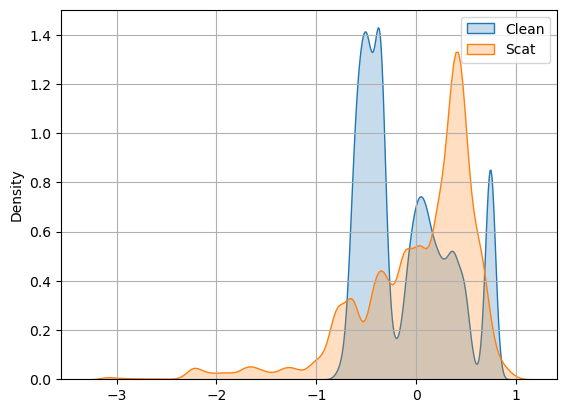

In [5]:
errors = (ground_truth - preds).cpu()
len_seg = int(len(errors)/4)
id = 30

sns.kdeplot(errors[:len_seg,id], label='Clean', fill=True)
#sns.kdeplot(errors[len_seg:2*len_seg,id], label='Tomte', fill=True)
#sns.kdeplot(errors[2*len_seg:3*len_seg,id], label='Whistle', fill=True)
sns.kdeplot(errors[3*len_seg:,id], label='Scat', fill=True)
plt.legend()
#plt.xlim(-1.5, 1.5)
plt.grid()